# Telco Customer Churn — Exploratory Data Analysis

**Dataset:** Telco Customer Churn (7,043 records, 21 columns)  
**Goal:** Understand patterns in customer churn before building the ETL pipeline  
**Author:** Kavish Rathod


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# just so plots show inline
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded")

Libraries loaded


In [2]:
df = pd.read_csv("../data/raw/telco_churn_raw.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,GTOK-7469,Male,0,No,No,18,Yes,No,DSL,Yes,...,No internet service,No internet service,No,Yes,Month-to-month,No,Bank transfer (automatic),97.18,1679.32,No
1,SWKK-7437,Male,0,No,No,14,Yes,Yes,No,No,...,Yes,No internet service,Yes,No internet service,Month-to-month,Yes,Mailed check,83.74,1227.97,No
2,XCVU-1751,Female,1,Yes,Yes,33,Yes,No,No,No internet service,...,No internet service,No,No,No,Month-to-month,Yes,Mailed check,22.22,677.16,No
3,UALZ-5809,Male,0,No,No,63,Yes,Yes,No,No internet service,...,Yes,No,Yes,No internet service,Month-to-month,Yes,Electronic check,85.77,5076.31,No
4,POOS-6382,Female,0,Yes,No,48,Yes,No,No,Yes,...,Yes,Yes,No internet service,No,Two year,Yes,Credit card (automatic),99.55,4835.75,No


## 1. Basic Info & Data Types

First thing I do - check shape, dtypes, and if anything looks off

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.158455,35.016328,68.667772
std,0.365193,20.671004,29.034589
min,0.000000,0.000000,18.000000
25%,0.000000,17.000000,43.180000
50%,0.000000,35.000000,69.240000
75%,0.000000,53.000000,93.910000
max,1.000000,71.000000,118.000000


## 2. Missing Values

Checking for nulls - TotalCharges is known to have blank strings for new customers (tenure = 0)

In [5]:
# check missing
print("Null counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# TotalCharges has blank strings - not caught by isnull()
print("\nBlank TotalCharges (new customers):", (df["TotalCharges"].str.strip() == "").sum())

Null counts:
Series([], dtype: int64)

Blank TotalCharges (new customers): 100


In [6]:
# fix it - convert to numeric, blanks become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")

print("After fix - null TotalCharges:", df["TotalCharges"].isnull().sum())
print("These are all customers with tenure = 0:")
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]].head()

After fix - null TotalCharges: 100
These are all customers with tenure = 0:


,tenure,MonthlyCharges,TotalCharges
11,0,111.65,NaN
17,0,34.63,NaN
61,0,74.40,NaN
63,0,62.39,NaN
82,0,93.08,NaN


## 3. Churn Distribution

How many customers actually churned?

In [7]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print(f"\nChurn rate: {churn_counts['Yes'] / len(df) * 100:.2f}%")

Churn
No     5213
Yes    1830
Name: count, dtype: int64

Churn rate: 25.98%


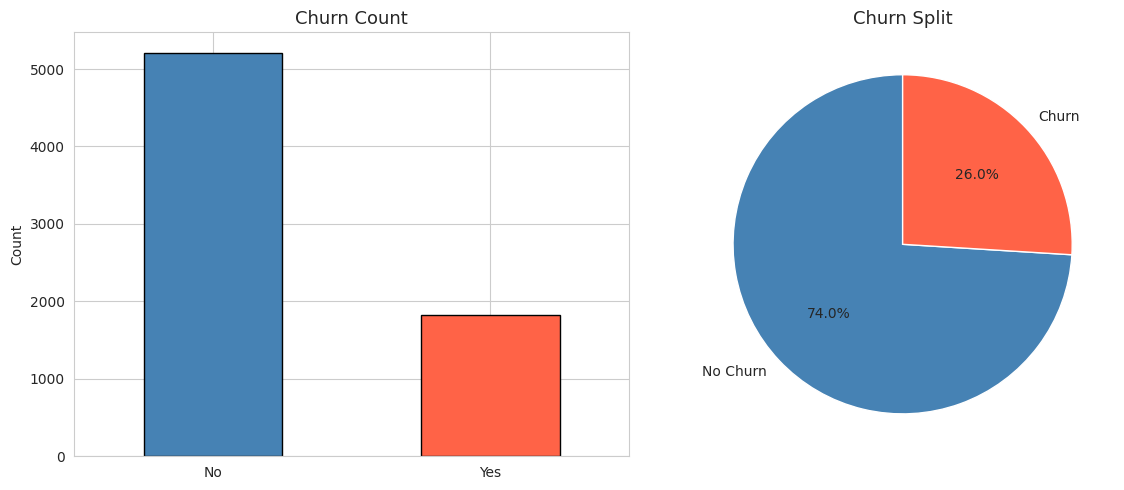

Plot saved


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# bar chart
churn_counts.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Churn Count", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(rotation=0)

# pie chart
axes[1].pie(churn_counts, labels=["No Churn", "Churn"], autopct="%1.1f%%",
            colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Churn Split", fontsize=13)

plt.tight_layout()
plt.savefig("../outputs/churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved")

## 4. Contract Type vs Churn

Hypothesis: month-to-month customers churn more - easier to leave

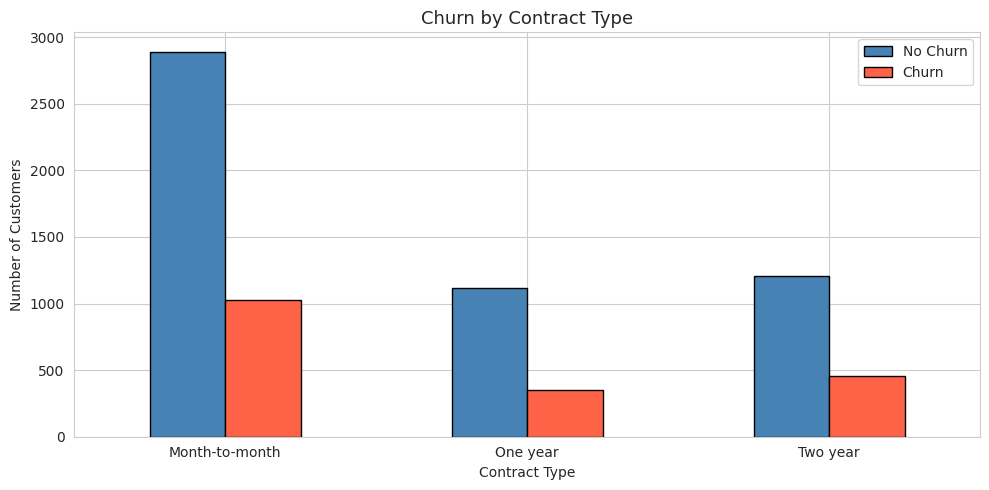

In [9]:
contract_churn = df.groupby(["Contract", "Churn"]).size().unstack()
contract_churn.plot(kind="bar", color=["steelblue", "tomato"], edgecolor="black", figsize=(10, 5))
plt.title("Churn by Contract Type", fontsize=13)
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["No Churn", "Churn"])
plt.tight_layout()
plt.savefig("../outputs/contract_churn.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Month-to-month customers churn at a much higher rate compared to 1-year or 2-year contract holders. Makes sense - no commitment = easier to leave.

## 5. Tenure Distribution

Do long-tenure customers churn less?

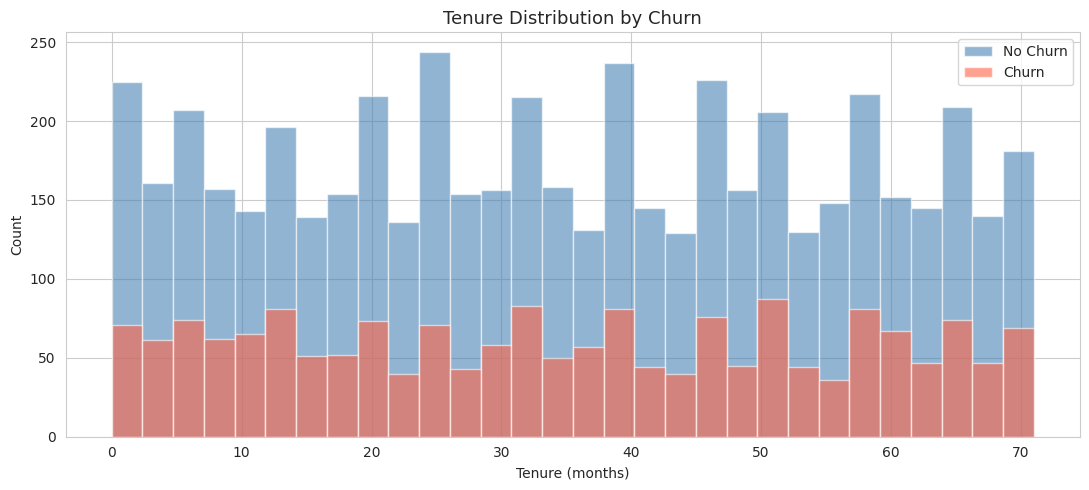

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))

df[df["Churn"] == "No"]["tenure"].hist(bins=30, alpha=0.6, color="steelblue", label="No Churn", ax=ax)
df[df["Churn"] == "Yes"]["tenure"].hist(bins=30, alpha=0.6, color="tomato", label="Churn", ax=ax)

ax.set_title("Tenure Distribution by Churn", fontsize=13)
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/tenure_churn.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Customers who churn tend to have very low tenure (0-12 months). Long-term customers (48+ months) are much more loyal. This is why `tenure_group` was added as a feature in the ETL pipeline.

## 6. Monthly Charges vs Churn

Do higher paying customers leave more?

/tmp/ipykernel_69/544163449.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette={"No": "steelblue", "Yes": "tomato"})


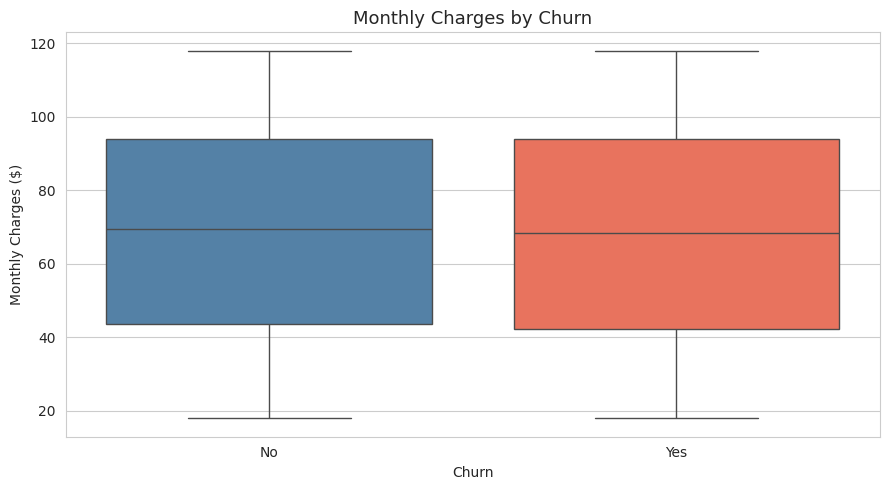

Avg monthly charge - No Churn: 68.74
Avg monthly charge - Churn:    68.48


In [11]:
plt.figure(figsize=(9, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette={"No": "steelblue", "Yes": "tomato"})
plt.title("Monthly Charges by Churn", fontsize=13)
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")
plt.tight_layout()
plt.savefig("../outputs/monthly_charges_churn.png", dpi=150, bbox_inches="tight")
plt.show()

print("Avg monthly charge - No Churn:", round(df[df["Churn"]=="No"]["MonthlyCharges"].mean(), 2))
print("Avg monthly charge - Churn:   ", round(df[df["Churn"]=="Yes"]["MonthlyCharges"].mean(), 2))

## 7. Internet Service vs Churn

Fiber optic customers - do they churn more?

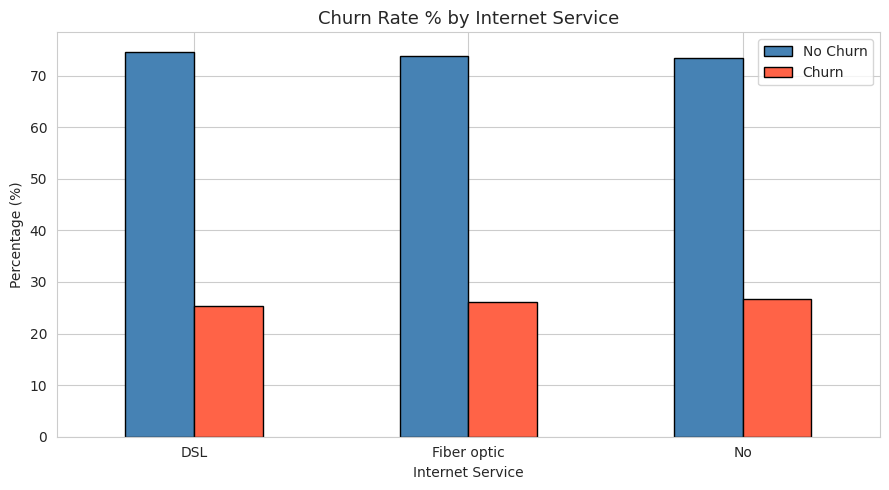

In [12]:
internet_churn = df.groupby(["InternetService", "Churn"]).size().unstack(fill_value=0)
internet_churn_pct = internet_churn.div(internet_churn.sum(axis=1), axis=0) * 100

internet_churn_pct.plot(kind="bar", color=["steelblue", "tomato"], edgecolor="black", figsize=(9, 5))
plt.title("Churn Rate % by Internet Service", fontsize=13)
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(["No Churn", "Churn"])
plt.tight_layout()
plt.savefig("../outputs/internet_churn.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Payment Method vs Churn

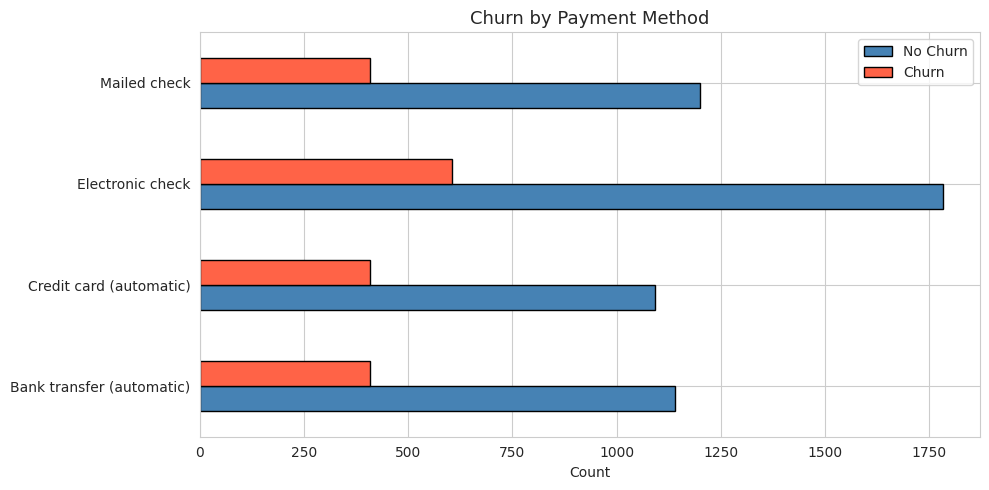

In [13]:
pay_churn = df.groupby(["PaymentMethod", "Churn"]).size().unstack(fill_value=0)
pay_churn.plot(kind="barh", color=["steelblue", "tomato"], edgecolor="black", figsize=(10, 5))
plt.title("Churn by Payment Method", fontsize=13)
plt.xlabel("Count")
plt.ylabel("")
plt.legend(["No Churn", "Churn"])
plt.tight_layout()
plt.savefig("../outputs/payment_churn.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Correlation Heatmap

Quick check - which numeric features correlate with each other?

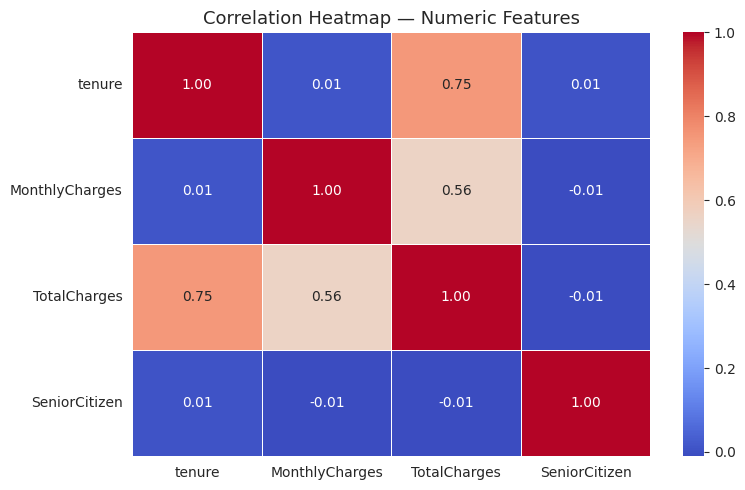

In [14]:
df_numeric = df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]].copy()
df_numeric["TotalCharges"] = df_numeric["TotalCharges"].fillna(df_numeric["TotalCharges"].median())

plt.figure(figsize=(8, 5))
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap — Numeric Features", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Summary — Key Findings

| Finding | Insight |
|---|---|
| Churn rate | ~26% of customers churned |
| Contract type | Month-to-month customers churn significantly more |
| Tenure | Low tenure (0-12 months) = high churn risk |
| Monthly charges | Churned customers pay higher monthly charges on average |
| Internet service | Fiber optic customers churn more than DSL |
| Payment method | Electronic check users show highest churn |

These findings guided the feature engineering in the ETL pipeline:
- Added `tenure_group` to bucket customers by loyalty stage
- Added `avg_monthly_spend` to capture spending behaviour


## Next Steps

- ETL pipeline processes and cleans this data → `pipeline.py`
- Cleaned output loaded into MySQL / CSV for dashboard use
- Power BI dashboard built on top of `outputs/telco_churn_final.csv`
